# Two Neuron Day 9 (08/01/2026)
***Vectors & ML-Ready Dataset***

**Neuron A**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#Time parameters
dt=0.1
T=100
time=np.arange(0,T,dt)

# Neuron A parameters
V_rest_A=-65
V_A=np.zeros(len(time))
V_A[0]=V_rest_A

#Input Current (constant)
I_A = 6
tau_A=10

# Spikes A
V_th_A = -63
V_reset_A = -65
spikes_A= np.zeros(len(time))

#Refractory period 
refractory_period_A = 2
refractory_steps_A = int(refractory_period_A / dt)
refractory_timer_A= 0

#Noise
noise_std = 1
noise = np.random.normal(0,noise_std,len(time))

#Voltage update loop
for t in range(1,len(time)):
    if refractory_timer_A >0:
        V_A[t] = V_reset_A
        refractory_timer_A -= 1

    else:
        I_t = I_A+noise[t]
        dV_A= (-(V_A[t-1] - V_rest_A ) + I_t) * (dt/tau_A)
        V_A[t] = V_A[t-1] + dV_A

        if V_A[t] >= V_th_A :
            spikes_A[t] = 1
            V_A[t] = V_reset_A
            refractory_timer_A = refractory_steps_A

#Firing rate calculation
total_spikes_A = np.sum(spikes_A)
total_time_sec_A= T/1000

firing_rate_A = total_spikes_A / total_time_sec_A
firing_rate_A

np.float64(160.0)

**Spike Count Neuron A**

In [2]:
spike_count_A = np.sum(spikes_A)
spike_count_A

np.float64(16.0)

**Neuron A Graph**

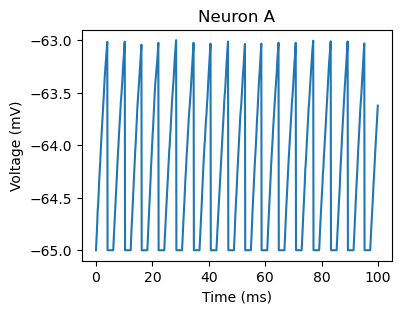

In [3]:
plt.figure(figsize=(4,3))
plt.plot(time,V_A)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Neuron A")
plt.show()

**Spike Train Neuron A**

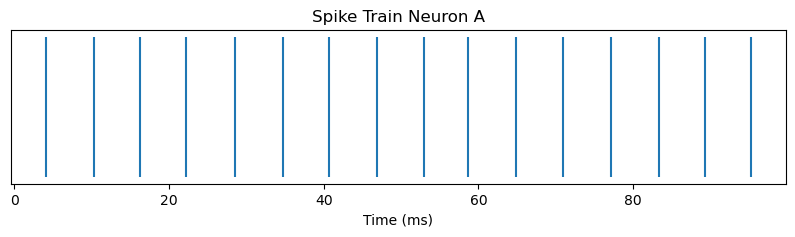

In [4]:
spike_times_A = time[spikes_A == 1]

plt.figure(figsize=(10,2))
plt.vlines(spike_times_A,ymin=0,ymax=1)
plt.xlabel("Time (ms)")
plt.yticks([])
plt.title("Spike Train Neuron A")
plt.show()

**Neuron B**

In [5]:
#Neuron A parameters 
V_rest_B = -65
V_B = np.zeros(len(time))
V_B[0] = V_rest_B

#Input Current (comes from Neuron A) 
# Synapthic connection from A-> B
w_AB = 15 + 10 * np.sin(2 * np.pi * np.arange(len(time)) / len(time))
I_B= np.zeros(len(time))
syn_current_B = np.zeros(len(time))

#Inhibitory synapse from A-> B
w_AiB = 2.5
syn_current_inh_B = np.zeros(len(time))

# Synaptic decay constants
alpha_exc = 0.90    # slow decay (excitation accumulates)
alpha_inh = 0.85    # faster decay (inhibition is brief)

#Spikes
V_th_B = -63
V_reset_B = -65
spikes_B = np.zeros(len(time))

#Refractory period
refractory_period_B = 2
refractory_steps_B = int(refractory_period_B / dt)
refractory_timer_B =0

# Voltage update loop for Neuron B
for t in range(1,len(time)):
    # Excitatory synapse (A -> B)
    syn_current_B[t] = (
        alpha_exc * syn_current_B[t-1]
        + w_AB[t] * spikes_A[t-1]
    )

    # Inhibitory synapse (A -> B)
    syn_current_inh_B[t] = (
        alpha_inh * syn_current_inh_B[t-1]
        + w_AiB * spikes_A[t-1]
    )

    # Net synaptic input
    I_B[t] = syn_current_B[t] - syn_current_inh_B[t]

    if refractory_timer_B>0:
        V_B[t] = V_reset_B
        refractory_timer_B-=1

    else:
        dV_B = (-(V_B[t-1] - V_rest_B) + I_B[t]) * (dt / tau_A)
        V_B[t] = V_B[t-1] + dV_B

        if V_B[t] >= V_th_B:
            spikes_B[t]=1
            V_B[t] = V_reset_B
            refractory_timer_B = refractory_steps_B

#Firing rate calculation
total_spikes_B = np.sum(spikes_B)
total_time_sec_B= T/1000

firing_rate_B = total_spikes_B / total_time_sec_B
firing_rate_B

np.float64(40.0)

**Spike Count Neuron B**

In [6]:
spike_count_B = np.sum(spikes_B)
spike_count_B

np.float64(4.0)

**Neuron B Graph**

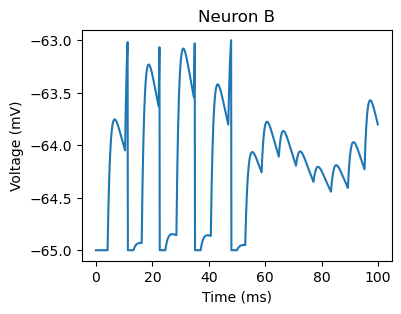

In [7]:
plt.figure(figsize=(4,3))
plt.plot(time,V_B)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Neuron B")
plt.show()

**Spike Train Neuron B**

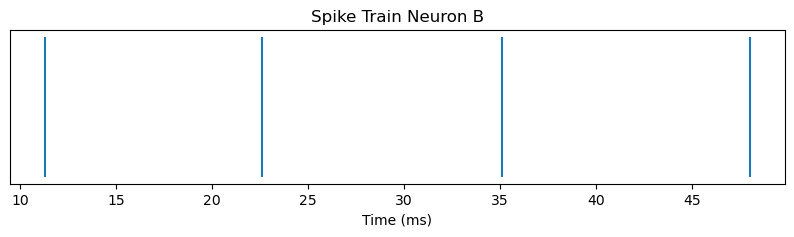

In [8]:
spike_times_B = time[spikes_B == 1]

plt.figure(figsize = (10,2))
plt.vlines(spike_times_B,ymin=0,ymax=1)
plt.xlabel("Time (ms)")
plt.yticks([])
plt.title("Spike Train Neuron B")
plt.show()

**Inter-Spike Interal (ISI)**

In [9]:
spike_times_A = time[spikes_A == 1]
spike_times_B = time[spikes_B == 1]

isi_A = np.diff(spike_times_A)
isi_B = np.diff(spike_times_B)

len(isi_A),len(isi_B)

(15, 3)

In [10]:
# mean ISI
mean_isi_A = np.mean(isi_A)
mean_isi_B = np.mean(isi_B)

mean_isi_A,mean_isi_B

(np.float64(6.073333333333334), np.float64(12.233333333333334))

In [11]:
# isi variance
std_isi_A = np.std(isi_A)
std_isi_B = np.std(isi_B)

std_isi_A,std_isi_B

(np.float64(0.13888444437333256), np.float64(0.6798692684790372))

In [12]:
# Coefficient of Variations (CV)
cv_A = np.std(isi_A)/ np.mean(isi_A)
cv_B = np.std(isi_B)/ np.mean(isi_B)
cv_A,cv_B

(np.float64(0.022867910709110737), np.float64(0.05557514456231911))

**Plot ISI for A**

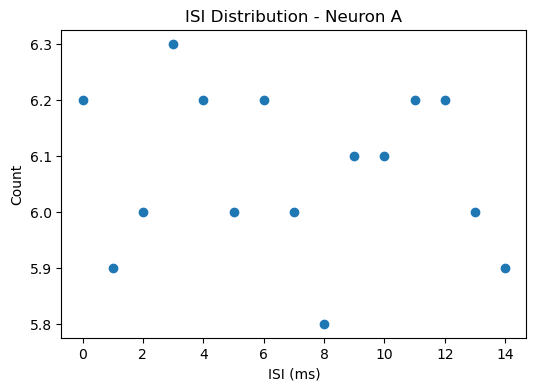

In [13]:
plt.figure(figsize=(6,4))
plt.plot(isi_A,'o')
plt.xlabel("ISI (ms)")
plt.ylabel("Count")
plt.title("ISI Distribution - Neuron A")
plt.show()

Plotting inter-spike intervals (ISI) as individual values shows that all ISIs collapse to a single constant value.
This indicates highly regular, tonic firing behavior of the neuron under constant input.
Such deterministic firing patterns are characteristic of LIF neurons without noise or time-varying inputs.
This regular baseline serves as a reference for later comparisons involving inhibition, noise, or modulation.

**Plot ISI for B**

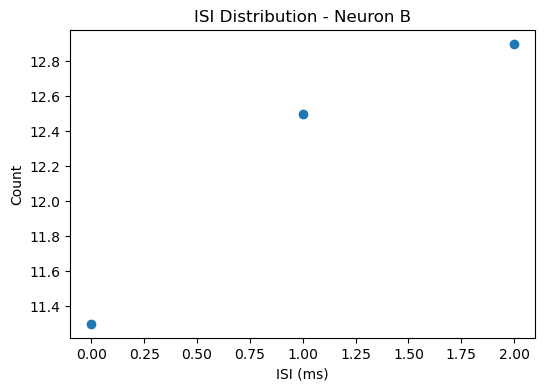

In [14]:
plt.figure(figsize=(6,4))
plt.plot(isi_B,'o')
plt.xlabel("ISI (ms)")
plt.ylabel("Count")
plt.title("ISI Distribution - Neuron B")
plt.show()

# Feature Vectors

In [15]:
# Feature Vector Neuron A
features_A = {
    "spike_count" : spike_count_A,
    "firing_rate" : firing_rate_A,
    "mean_isi" : np.mean(isi_A),
    "std_isi" : np.std(isi_A),
    "cv" : np.std(isi_A) / np.mean(isi_A)
}

features_A

{'spike_count': np.float64(16.0),
 'firing_rate': np.float64(160.0),
 'mean_isi': np.float64(6.073333333333334),
 'std_isi': np.float64(0.13888444437333256),
 'cv': np.float64(0.022867910709110737)}

In [16]:
# Feature Vector Neuron B
if len(isi_B) > 1:
    mean_isi_B = np.mean(isi_B)
    std_isi_B = np.std(isi_B)
    cv_B = std_isi_B / mean_isi_B
else:
    mean_isi_B = np.nan
    std_isi_B = np.nan
    cv_B = np.nan

features_B = {
    "spike_count" : spike_count_B,
    "firing_rate" : firing_rate_B,
    "mean_isi" : mean_isi_B,
    "std_isi" : std_isi_B,
    "cv" : cv_B
}

features_B

{'spike_count': np.float64(4.0),
 'firing_rate': np.float64(40.0),
 'mean_isi': np.float64(12.233333333333334),
 'std_isi': np.float64(0.6798692684790372),
 'cv': np.float64(0.05557514456231911)}

In [17]:
#Feature Table
import pandas as pd

feature_table = pd.DataFrame(
    [features_A,features_B],
    index=["Neuron_A", "Neuron_B"]
)
feature_table

,spike_count,firing_rate,mean_isi,std_isi,cv
Neuron_A,16.0,160.0,6.073333,0.138884,0.022868
Neuron_B,4.0,40.0,12.233333,0.679869,0.055575


# Observation
Spike train features were organized into structured feature vectors including spike count, firing rate, mean ISI, ISI variability, and coefficient of variation.
These features provide a compact numerical summary of neural dynamics under different input conditions.
Organizing features into tabular form enables direct compatibility with machine learning pipelines while preserving interpretability rooted in neural behavior.

Implementing temporally integrated excitatory and inhibitory synapses reveals how synaptic dynamics regulate postsynaptic firing.
Differential decay of excitatory and inhibitory currents allows excitation to accumulate while inhibition gates activity.
Balanced synaptic inputs produce irregular spiking patterns, demonstrating circuit-level control of neural dynamics.